<a href="https://colab.research.google.com/github/Tsanami/HSE_DL_2026/blob/HW6/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim import AdamW
import time
import matplotlib.pyplot as plt


#Механизмы Внимания

In [ ]:
class MHLA(nn.Module):
    def __init__(self, dim, num_heads_mhla=16, feature_map='relu', eps=1e-6, locality_init=True):
        super().__init__()
        self.dim = dim
        self.M = num_heads_mhla
        self.eps = eps
        self.feature_map = feature_map
        self.locality_init = locality_init

        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim, bias=False)

        self.mixing_coeff = nn.Parameter(torch.zeros(self.M, self.M))

        if self.locality_init:
            self._init_locality_biased()
        else:
            nn.init.uniform_(self.mixing_coeff, 0.3, 0.7)
            self.mixing_coeff.data = F.softmax(self.mixing_coeff.data, dim=-1)

    def _init_locality_biased(self):
        side = int(self.M ** 0.5)
        assert side * side == self.M, f"M={self.M} должно быть полным квадратом"
        coords = [(i, j) for i in range(side) for j in range(side)]
        for i in range(self.M):
            row = []
            for j in range(self.M):
                dist = ((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)**0.5
                max_dist = ((side-1)**2 + (side-1)**2)**0.5
                row.append(1.0 - dist / max_dist)
            self.mixing_coeff.data[i] = torch.tensor(row)
        self.mixing_coeff.data = F.softmax(self.mixing_coeff.data * 5.0, dim=-1)

    def feature_map_fn(self, x):
        if self.feature_map == 'relu':
            return F.relu(x) + self.eps
        return F.elu(x) + 1.0

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        original_N = N

        if H is None or W is None:
            H = W = int(N ** 0.5)
            if H * W != N:
                H = int(N ** 0.5) + 1
                W = H

        q = self.feature_map_fn(self.to_q(x))
        k = self.feature_map_fn(self.to_k(x))
        v = self.to_v(x)

        H_b = int(self.M ** 0.5)
        W_b = H_b

        # Reshape to 2D spatial
        q_2d = rearrange(q, 'B (H W) D -> B H W D', H=H, W=W)
        k_2d = rearrange(k, 'B (H W) D -> B H W D', H=H, W=W)
        v_2d = rearrange(v, 'B (H W) D -> B H W D', H=H, W=W)

        # Вычисляем необходимый паддинг, чтобы H и W делились на H_b и W_b
        pad_h = (H_b - H % H_b) % H_b
        pad_w = (W_b - W % W_b) % W_b

        # Добавляем паддинг (нули) по пространственным измерениям
        if pad_h > 0 or pad_w > 0:
            # F.pad формат: (W_left, W_right, H_top, H_bottom) для последних двух размерностей
            q_2d = F.pad(q_2d, (0, 0, 0, pad_w, 0, pad_h))
            k_2d = F.pad(k_2d, (0, 0, 0, pad_w, 0, pad_h))
            v_2d = F.pad(v_2d, (0, 0, 0, pad_w, 0, pad_h))
            H = H + pad_h
            W = W + pad_w

        h_per_block = H // H_b
        w_per_block = W // W_b

        q_blocks = rearrange(q_2d, 'B (Hb hp) (Wb wp) D -> B (Hb Wb) (hp wp) D', Hb=H_b, hp=h_per_block, Wb=W_b, wp=w_per_block)
        k_blocks = rearrange(k_2d, 'B (Hb hp) (Wb wp) D -> B (Hb Wb) (hp wp) D', Hb=H_b, hp=h_per_block, Wb=W_b, wp=w_per_block)
        v_blocks = rearrange(v_2d, 'B (Hb hp) (Wb wp) D -> B (Hb Wb) (hp wp) D', Hb=H_b, hp=h_per_block, Wb=W_b, wp=w_per_block)

        kv_summary = torch.einsum('b m n d, b m n e -> b m d e', k_blocks, v_blocks)
        z_summary = k_blocks.sum(dim=2)

        coeff = torch.clamp(self.mixing_coeff, min=1e-6, max=1.0)
        coeff = F.normalize(coeff, p=1, dim=-1)

        mixed_kv = torch.einsum('i m, b m d e -> b i d e', coeff, kv_summary)
        mixed_z = torch.einsum('i m, b m d -> b i d', coeff, z_summary)

        numerator = torch.einsum('b i n d, b i d e -> b i n e', q_blocks, mixed_kv)
        denominator = torch.einsum('b i n d, b i d -> b i n', q_blocks, mixed_z).unsqueeze(-1).clamp(min=self.eps)

        output_blocks = numerator / denominator
        output = rearrange(output_blocks, 'B (Hb Wb) (hp wp) D -> B (Hb hp Wb wp) D', Hb=H_b, Wb=W_b, hp=h_per_block, wp=w_per_block)

        # Убираем паддинг, чтобы вернуть исходную длину последовательности
        if output.shape[1] > original_N:
            output = output[:, :original_N]

        return self.to_out(output)


class VanillaLinearAttention(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        q = F.relu(self.to_q(x)) + self.eps
        k = F.relu(self.to_k(x)) + self.eps
        v = self.to_v(x)

        kv = torch.einsum('b n d, b n e -> b d e', k, v)
        k_sum = k.sum(dim=1)

        num = torch.einsum('b n d, b d e -> b n e', q, kv)
        den = torch.einsum('b n d, b d -> b n', q, k_sum).unsqueeze(-1).clamp(min=self.eps)
        return self.to_out(num / den)

class StandardSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=6):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.num_heads), qkv)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = attn @ v
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

# Трансформер

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, attn_module, mlp_ratio=4., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = attn_module
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, H=None, W=None):
        x = x + self.attn(self.norm1(x), H=H, W=W)
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=100, dim=192, depth=6, attn_type='mhla', dropout=0.1):
        super().__init__()
        self.H = img_size // patch_size
        self.W = img_size // patch_size

        self.patch_embed = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)

        # УБРАЛИ cls_token!
        self.pos_embed = nn.Parameter(torch.randn(1, self.H*self.W, dim) * 0.02)

        if attn_type == 'mhla':
            M = 16
            attn_fn = lambda: MHLA(dim, num_heads_mhla=M)
        elif attn_type == 'linear':
            attn_fn = lambda: VanillaLinearAttention(dim)
        elif attn_type == 'softmax':
            attn_fn = lambda: StandardSelfAttention(dim, num_heads=6)
        else:
            raise ValueError(f"Unknown attn_type: {attn_type}")

        self.blocks = nn.ModuleList([
            TransformerBlock(dim, attn_fn(), dropout=dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = rearrange(x, 'b d h w -> b (h w) d')

        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x, H=self.H, W=self.W)

        x = self.norm(x)

        # Global Average Pooling вместо CLS токена
        # Усредняем признаки по всем патчам -> [B, D]
        x = x.mean(dim=1)

        return self.head(x)

# Обучение

In [ ]:
def train_and_evaluate(attn_type, device, epochs=5):
    print(f"\n{'='*50}\nTraining with: {attn_type}\n{'='*50}")

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5071, 0.4867, 0.4408], [0.2675, 0.2565, 0.2761]),
    ])

    train_dataset = datasets.CIFAR100('./data', train=True, download=True, transform=transform)
    val_dataset = datasets.CIFAR100('./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    model = VisionTransformer(dim=192, depth=6, attn_type=attn_type).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params / 1e6:.2f}M")

    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'epoch_time': [],
        'params_M': n_params / 1e6
    }

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        start = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

        train_acc = correct / total
        elapsed = time.time() - start

        # Валидация
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += images.size(0)
        val_acc = val_correct / val_total

        # Сохраняем метрики эпохи
        history['train_loss'].append(total_loss/total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(elapsed)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/total:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    return model, history

def plot_results(histories):
    """Строит графики Loss и Accuracy"""

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    colors = {'softmax': 'blue', 'linear': 'red', 'mhla': 'green'}

    for attn_type, history in histories.items():
        epochs = range(1, len(history['train_loss']) + 1)
        c = colors.get(attn_type, 'black')

        # График Loss
        axs[0].plot(epochs, history['train_loss'], label=attn_type, color=c)
        # График Train Acc
        axs[1].plot(epochs, history['train_acc'], label=attn_type, color=c)
        # График Val Acc
        axs[2].plot(epochs, history['val_acc'], label=attn_type, color=c)

    axs[0].set_title('Training Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].set_title('Training Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)

    axs[2].set_title('Validation Accuracy')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Accuracy')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

def print_summary_table(histories):
    """Выводит сводную таблицу результатов в терминал"""
    print("\n" + "="*70)
    print(f"{'SUMMARY TABLE':^70}")
    print("="*70)
    print(f"{'Attention':<15} | {'Params (M)':<10} | {'Best Val Acc':<12} | {'Total Time (s)':<15} | {'Avg Epoch (s)':<15}")
    print("-" * 70)

    for attn_type, history in histories.items():
        best_val_acc = max(history['val_acc'])
        total_time = sum(history['epoch_time'])
        avg_time = total_time / len(history['epoch_time'])
        params = history['params_M']

        print(f"{attn_type:<15} | {params:<10.2f} | {best_val_acc:<12.4f} | {total_time:<15.1f} | {avg_time:<15.1f}")

    print("="*70)

Using device: cuda

Training with: softmax
Parameters: 2.87M
Epoch 1/5 | Loss: 3.8717 | Train Acc: 0.1027 | Val Acc: 0.1474 | Time: 140.4s
Epoch 2/5 | Loss: 3.4623 | Train Acc: 0.1702 | Val Acc: 0.1928 | Time: 139.7s
Epoch 3/5 | Loss: 3.2687 | Train Acc: 0.2027 | Val Acc: 0.2235 | Time: 137.3s
Epoch 4/5 | Loss: 3.1163 | Train Acc: 0.2305 | Val Acc: 0.2440 | Time: 135.7s
Epoch 5/5 | Loss: 2.9817 | Train Acc: 0.2554 | Val Acc: 0.2523 | Time: 135.6s

Training with: linear
Parameters: 2.87M
Epoch 1/5 | Loss: 3.8996 | Train Acc: 0.0981 | Val Acc: 0.1379 | Time: 122.4s
Epoch 2/5 | Loss: 3.4861 | Train Acc: 0.1620 | Val Acc: 0.1822 | Time: 122.8s
Epoch 3/5 | Loss: 3.3055 | Train Acc: 0.1921 | Val Acc: 0.2082 | Time: 125.4s
Epoch 4/5 | Loss: 3.1609 | Train Acc: 0.2225 | Val Acc: 0.2328 | Time: 123.3s
Epoch 5/5 | Loss: 2.9883 | Train Acc: 0.2511 | Val Acc: 0.2642 | Time: 124.8s

Training with: mhla
Parameters: 2.87M
Epoch 1/5 | Loss: 3.7220 | Train Acc: 0.1264 | Val Acc: 0.1946 | Time: 220.1s
E

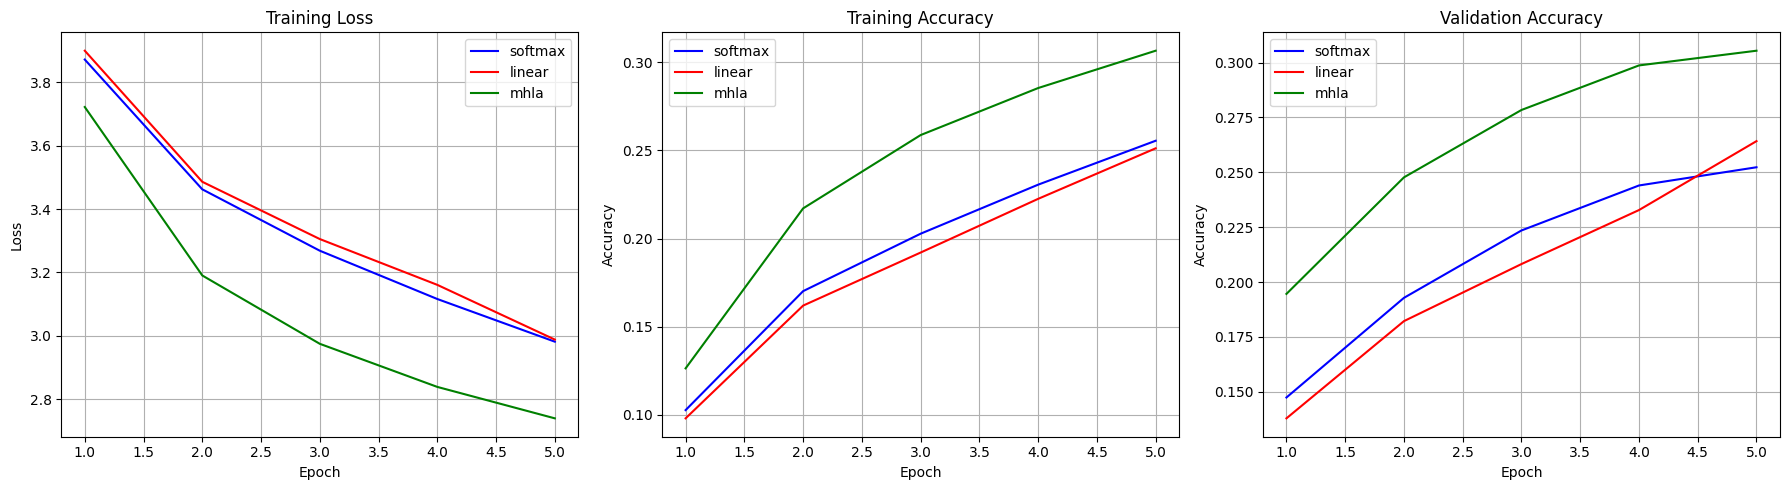

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

EPOCHS = 5

models = {}
histories = {}

for attn_type in ['softmax', 'linear', 'mhla']:
    model, history = train_and_evaluate(attn_type, device, epochs=EPOCHS)
    models[attn_type] = model
    histories[attn_type] = history

plot_results(histories)

In [ ]:
print_summary_table(histories)


                            SUMMARY TABLE                             
Attention       | Params (M) | Best Val Acc | Total Time (s)  | Avg Epoch (s)  
----------------------------------------------------------------------
softmax         | 2.87       | 0.2523       | 688.7           | 137.7          
linear          | 2.87       | 0.2642       | 618.8           | 123.8          
mhla            | 2.87       | 0.3054       | 1102.9          | 220.6          


# Замер механизмов на различных разрешениях

In [ ]:
def benchmark_attention():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Benchmarking on: {device}\n")

    models = {
        'Softmax': StandardSelfAttention(dim=192).to(device).eval(),
        'Linear': VanillaLinearAttention(dim=192).to(device).eval(),
        'MHLA': MHLA(dim=192, num_heads_mhla=16).to(device).eval()
    }

    # Тестируем разные разрешения (N = (res/16)^2)
    resolutions = [224, 448, 896, 1792] # N = 196, 784, 3136, 12544

    for res in resolutions:
        H = W = res // 16
        N = H * W
        x = torch.randn(1, N, 192).to(device) # батч=1

        print(f"--- Resolution {res}x{res} | N = {N} tokens ---")
        for name, model in models.items():
            # Прогрев GPU
            with torch.no_grad():
                for _ in range(10):
                    _ = model(x, H=H, W=W)

            # Замер
            torch.cuda.synchronize() if device.type == 'cuda' else None
            start = time.time()

            with torch.no_grad():
                for _ in range(100):
                    _ = model(x, H=H, W=W)

            torch.cuda.synchronize() if device.type == 'cuda' else None
            elapsed = time.time() - start

            print(f"{name:<10}: {elapsed:.4f}s ({100/elapsed:.1f} iter/sec)")
        print()

benchmark_attention()

Benchmarking on: cuda

--- Resolution 224x224 | N = 196 tokens ---
Softmax   : 0.0336s (2973.7 iter/sec)
Linear    : 0.0441s (2269.6 iter/sec)
MHLA      : 0.1257s (795.3 iter/sec)

--- Resolution 448x448 | N = 784 tokens ---
Softmax   : 0.0987s (1013.4 iter/sec)
Linear    : 0.0463s (2157.7 iter/sec)
MHLA      : 0.0952s (1050.6 iter/sec)

--- Resolution 896x896 | N = 3136 tokens ---
Softmax   : 1.0774s (92.8 iter/sec)
Linear    : 0.0737s (1356.6 iter/sec)
MHLA      : 0.0877s (1140.6 iter/sec)

--- Resolution 1792x1792 | N = 12544 tokens ---
Softmax   : 18.2502s (5.5 iter/sec)
Linear    : 0.3079s (324.8 iter/sec)
MHLA      : 0.3458s (289.2 iter/sec)



# Выводы
По точности и скорости схождения MHLA уверенно побеждает, особенно на ранних этапах обучения:  
MHLA (30.54%) > Linear (26.42%) > Softmax (25.23%) на 5-й эпохе.

Бенчмарки на разных разрешениях показывают сильный проигрыш квадратичной сложности  O(N^2):

На 1792x1792 Softmax тратит 18.25 секунды на проход, в то время как MHLA справляется за 0.34 секунды — разница в 53 раза

Точка пересечения: Когда MHLA оправдывает себя.
Данные доказывают, что линейное внимание не является панацеей для любых задач:

При 224x224: MHLA в 3.7 раза медленнее Softmax (795 vs 2973 iter/sec). Накладные расходы на rearrange, смешивание матриц и einsum делают его неэффективным на коротких последовательностях.
При 448x448: Происходит точка перелома. MHLA (1050 iter/sec) догоняет и обгоняет Softmax (1013 iter/sec).
Вывод: Использовать MHLA на картинках 224x224 бессмысленно с точки зрения скорости.